In [22]:
import pandas as pd
import numpy as np

adon = pd.read_csv("ADON.csv")
zen  = pd.read_csv("ZEN.csv")

adon.columns = ["wn", "adon"]
zen.columns  = ["wn", "zen"]

df = pd.merge_asof(
    adon.sort_values("wn"),
    zen.sort_values("wn"),
    on="wn",
    direction="nearest",
    tolerance=1  # allow 1 cm⁻¹ mismatch
)

print(df)



          wn    adon       zen
0      152.0   352.0  335.2892
1      153.0   353.0  333.6665
2      154.0   354.0  334.1483
3      154.0   353.0  334.1483
4      155.0   349.0  336.2163
...      ...     ...       ...
3335  3370.0  1210.0  360.5142
3336  3370.0  1210.0  360.5142
3337  3370.0  1210.0  360.5142
3338  3370.0  1220.0  360.5142
3339  3370.0  1220.0  360.5142

[3340 rows x 3 columns]


In [15]:
import numpy as np

X = df[["adon", "zen"]].T.values   # shape: 2 × N



In [16]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

# scale
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# PCA
pca = PCA(n_components=2)
scores = pca.fit_transform(X_scaled)

print("Explained variance:", pca.explained_variance_ratio_)
print("Scores:\n", scores)


Explained variance: [1.00000000e+00 1.12054106e-32]
Scores:
 [[ 3.31662479e+00 -3.51083347e-16]
 [-3.31662479e+00 -3.51083347e-16]]


In [17]:

# df contains: wn, adon, zen
X = df[["adon", "zen"]].T.values   # shape: 2 × N
labels = np.array(["ADON", "ZEN"])


In [18]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

pca = PCA(n_components=2)
scores = pca.fit_transform(X_scaled)
loadings = pca.components_


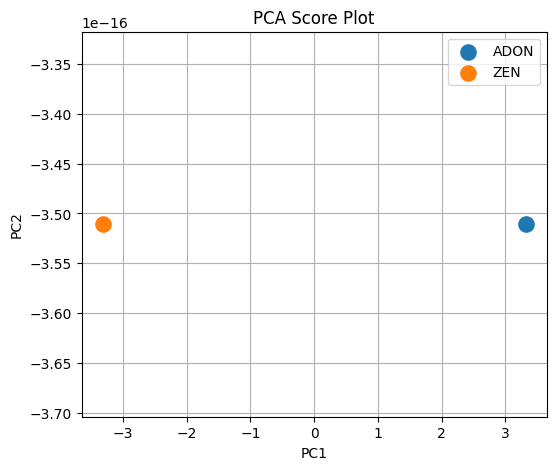

In [19]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,5))
for i, label in enumerate(labels):
    plt.scatter(scores[i,0], scores[i,1], label=label, s=120)

plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("PCA Score Plot")
plt.legend()
plt.grid(True)
plt.show()


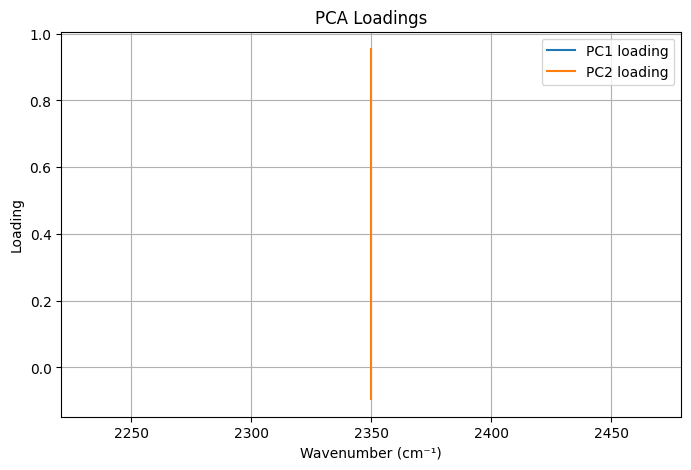

In [20]:
plt.figure(figsize=(8,5))
plt.plot(df["wn"], loadings[0], label="PC1 loading")
plt.plot(df["wn"], loadings[1], label="PC2 loading")
plt.xlabel("Wavenumber (cm⁻¹)")
plt.ylabel("Loading")
plt.title("PCA Loadings")
plt.legend()
plt.grid(True)
plt.show()
